
# Customer Analysis Project
## Amazon Alexa Review – Customer Sentiment Analysis

### Objective
Analyze Amazon Alexa customer reviews and classify feedback as positive or negative using NLP and Machine Learning.


In [ ]:

# Install required packages if not already installed
# Uncomment if needed:
# !pip install nltk wordcloud xgboost


In [ ]:

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Download stopwords
nltk.download('stopwords')



## Load Dataset

Make sure the dataset file `amazon_alexa.tsv` is present in the same folder as this notebook.


In [ ]:

# Load Dataset
try:
    df = pd.read_csv('amazon_alexa.tsv', sep='\t')
    print("Dataset Loaded Successfully")
except FileNotFoundError:
    print("Error: 'amazon_alexa.tsv' file not found.")


In [ ]:

# Display first 5 rows
df.head()



## Dataset Information


In [ ]:

# Shape of dataset
print("Dataset Shape:", df.shape)

# Dataset information
df.info()

# Null values
print("\nNull Values:")
print(df.isnull().sum())



## Exploratory Data Analysis


In [ ]:

# Feedback Distribution
plt.figure(figsize=(5,4))
sns.countplot(x='feedback', data=df)
plt.title('Feedback Distribution')
plt.show()


In [ ]:

# Rating Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='rating', data=df)
plt.title('Rating Distribution')
plt.show()



## Data Cleaning and Preprocessing


In [ ]:

# Initialize stemmer
ps = PorterStemmer()

# Fill missing reviews if any
df['verified_reviews'] = df['verified_reviews'].fillna('')

corpus = []

for review in df['verified_reviews']:
    
    # Remove special characters
    review = re.sub('[^a-zA-Z]', ' ', str(review))
    
    # Convert to lowercase
    review = review.lower()
    
    # Split words
    review = review.split()
    
    # Remove stopwords and apply stemming
    review = [ps.stem(word) for word in review if word not in stopwords.words('english')]
    
    # Join words
    review = ' '.join(review)
    
    corpus.append(review)

print("Text preprocessing completed.")
print(corpus[:5])



## Feature Extraction
Convert text data into numerical format using CountVectorizer.


In [ ]:

cv = CountVectorizer(max_features=2500)

X = cv.fit_transform(corpus).toarray()
y = df['feedback']

print("Feature Extraction Completed")
print("X Shape:", X.shape)



## Train Test Split


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)



## Model Training
Using Random Forest Classifier.


In [ ]:

# Train Model
model = RandomForestClassifier(random_state=42)

model.fit(X_train, y_train)

print("Model Training Completed")



## Prediction


In [ ]:

# Predictions
y_pred = model.predict(X_test)

print("Prediction Completed")



## Model Evaluation


In [41]:

# Accuracy Score
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)


Accuracy Score: 0.9238095238095239


In [ ]:

# Classification Report
print(classification_report(y_test, y_pred))


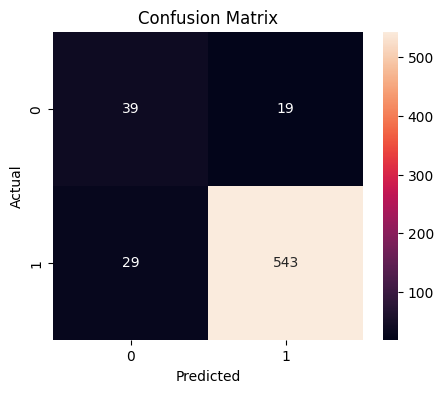

In [42]:

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [ ]:
print(df['feedback'].value_counts())

In [ ]:
from sklearn.linear_model import LogisticRegression

# Balanced Logistic Regression
model = LogisticRegression(class_weight='balanced', max_iter=1000)

# Train model
model.fit(X_train, y_train)

In [ ]:
import re

sample_reviews = [
    "The product quality is excellent and amazing",
    "I am very happy with this purchase",
    "The item is very bad and useless",
    "Worst product I have ever bought"
]

for review in sample_reviews:

    # Cleaning
    sample_review = re.sub('[^a-zA-Z]', ' ', review)
    sample_review = sample_review.lower()
    sample_review = sample_review.split()

    # Stemming only
    sample_review = [ps.stem(word) for word in sample_review]

    sample_review = ' '.join(sample_review)

    # Vectorization
    sample_vector = cv.transform([sample_review]).toarray()

    # Prediction
    prediction = model.predict(sample_vector)

    sentiment = "Positive Review" if prediction[0] == 1 else "Negative Review"

    print("Review :", review)
    print("Predicted Sentiment :", sentiment)
    print("-" * 60)

In [44]:
print(df.columns.tolist())


['rating', 'date', 'variation', 'verified_reviews', 'feedback']


In [36]:
!pip install wordcloud

Model Accuracy : 92.38095238095238


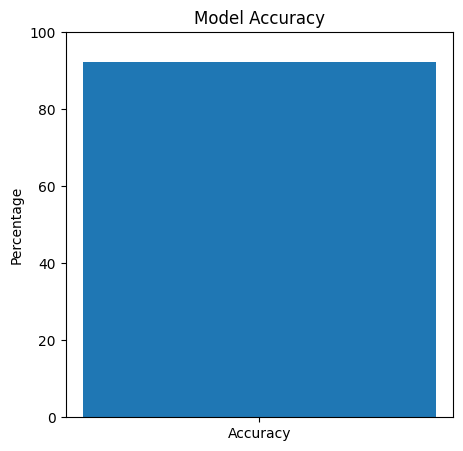

In [45]:
# ================================
# FINAL VISUALIZATION SECTION
# ================================

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
from wordcloud import WordCloud
import seaborn as sns

# ----------------------------
# Predictions
# ----------------------------

y_pred = model.predict(X_test)

# ----------------------------
# Accuracy
# ----------------------------

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy :", accuracy * 100)


# ----------------------------
# Accuracy Graph
# ----------------------------

plt.figure(figsize=(5,5))

plt.bar(
    ["Accuracy"],
    [accuracy * 100]
)

plt.ylim(0,100)

plt.title("Model Accuracy")

plt.ylabel("Percentage")

plt.show()



## Conclusion

- Most customer reviews are positive.
- Ratings 4 and 5 dominate the dataset.
- NLP preprocessing improves text quality.
- Random Forest successfully predicts customer sentiment.
- This analysis helps businesses understand customer satisfaction.


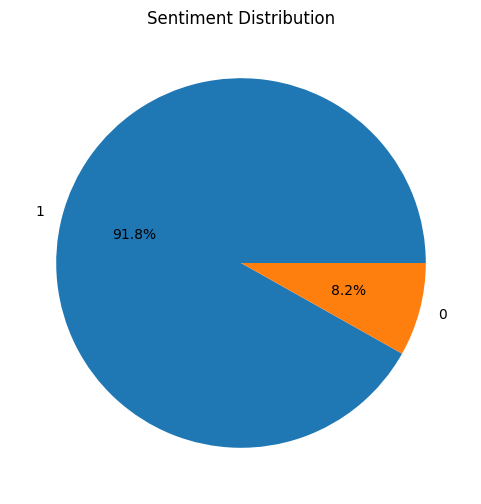

In [47]:
# Sentiment Pie Chart

sentiment_counts = df['feedback'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%'
)

plt.title("Sentiment Distribution")

plt.show()

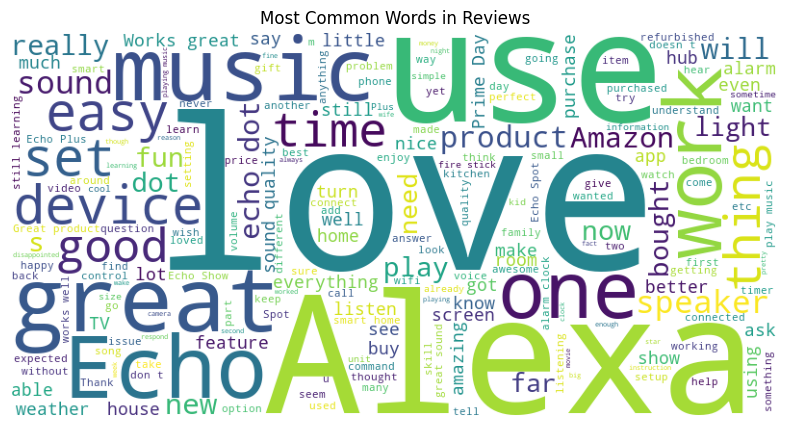

In [48]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
# WORD CLOUD

text = " ".join(df['verified_reviews'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Most Common Words in Reviews")

plt.show()